<a href="https://colab.research.google.com/github/Fushionek/MLTraining/blob/main/Supervised/basics/Salary_Progression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

path = kagglehub.dataset_download("krishnaraj30/salary-prediction-data-simple-linear-regression")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'salary-prediction-data-simple-linear-regression' dataset.
Path to dataset files: /kaggle/input/salary-prediction-data-simple-linear-regression


In [2]:
import pandas as pd

df = pd.read_csv(path + "/Salary_Data.csv")
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [4]:
df.isnull().sum()

,0
YearsExperience,0
Salary,0


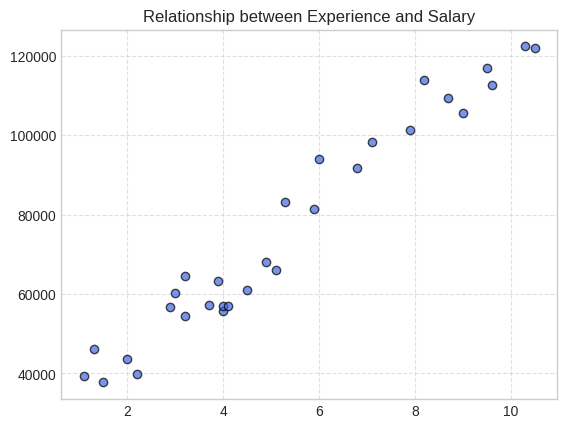

In [5]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

plt.scatter(df['YearsExperience'], df['Salary'], color='royalblue', alpha=0.7, edgecolors='k')

plt.title("Relationship between Experience and Salary")

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [6]:
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [7]:
X = df.drop(columns=['Salary'])
y = df.drop(columns=['YearsExperience'])

In [8]:
X

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [9]:
y

,Salary
0,39343.0
1,46205.0
2,37731.0
3,43525.0
4,39891.0
5,56642.0
6,60150.0
7,54445.0
8,64445.0
9,57189.0


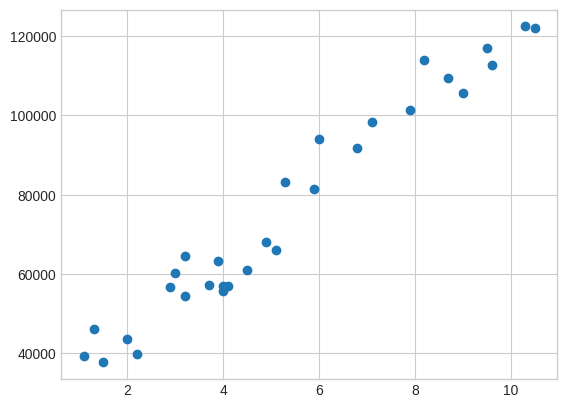

In [10]:
plt.scatter(X,y)

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(24, 1)
(6, 1)
(24, 1)
(6, 1)


In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
model = LinearRegression()

In [16]:
model.fit(X_train,y_train)

LinearRegression()

In [17]:
y_pred = model.predict(X_test)

In [18]:
print(y_pred)

[[115790.21011287]
 [ 71498.27809463]
 [102596.86866063]
 [ 75267.80422384]
 [ 55477.79204548]
 [ 60189.69970699]]


In [19]:
print(y_test)

      Salary
27  112635.0
15   67938.0
23  113812.0
17   83088.0
8    64445.0
9    57189.0


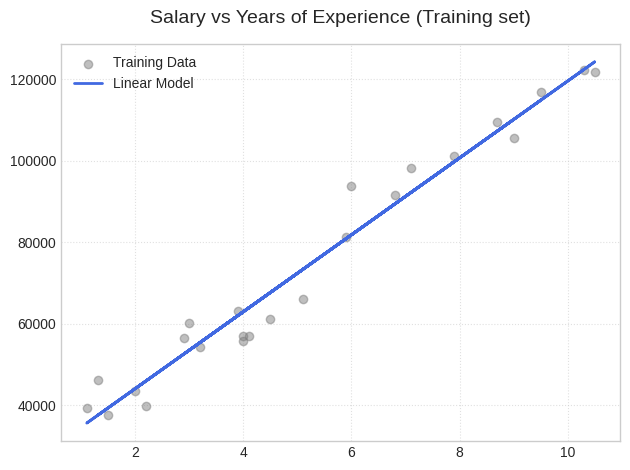

In [20]:
plt.scatter(X_train, y_train, color='gray', alpha=0.5, label='Training Data')

plt.plot(X_train, model.predict(X_train), color='royalblue', linewidth=2, label='Linear Model')

plt.title('Salary vs Years of Experience (Training set)', fontsize=14, pad=15)

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

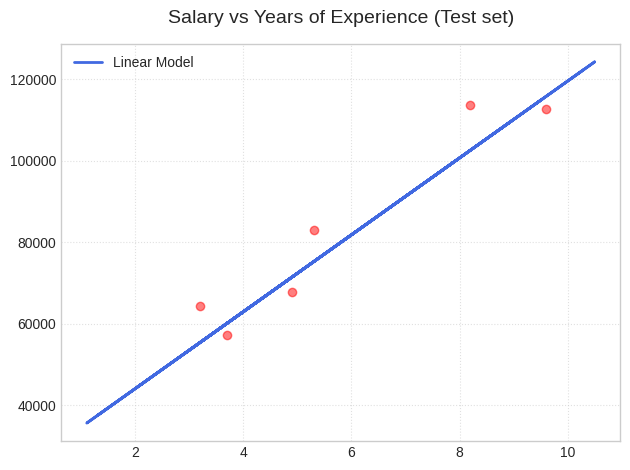

In [21]:
plt.scatter(X_test, y_test, color='red', alpha=0.5)

plt.plot(X_train, model.predict(X_train), color='royalblue', linewidth=2, label='Linear Model')

plt.title('Salary vs Years of Experience (Test set)', fontsize=14, pad=15)

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [22]:
from sklearn.metrics import mean_squared_error, r2_score

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

In [23]:
r2

0.9024461774180497

In [24]:
mse

49830096.85590839

In [25]:
print('Slope: ',model.coef_)
print('Intercept: ', model.intercept_)

Slope:  [[9423.81532303]]
Intercept:  [25321.58301178]


In [26]:
yofeexp = 10
salary = model.predict([[yofeexp]])
print(f'Przewidywana wyplata: {salary}')

Przewidywana wyplata: [[119559.73624209]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [27]:
yofeexp = 15
salary = model.predict([[yofeexp]])
print(f'Przewidywana wyplata: {salary}')

Przewidywana wyplata: [[166678.81285724]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
